### Использование ИИ

**Задания:** 1–5  
**Модель:** Grok 4.6

**Промпт 1**  
По df посчитай подневные конверсии view_item → add_to_cart → purchase по сессиям и построй лайнчарт конверсии по дням. Код простой, pandas и matplotlib, без комментариев.
Описание данных
- user_id — уникальный идентификатор пользователя
- session_id — уникальный идентификатор сессии
- event_ts — таймстемп событий
- platform — платформа, с которой пришло событие
- app_version — версия приложения (существует только для iOS и Android, для остальных платформ приходят значения-заглушки)
- region — регион пользователя
- channel — канал, с которого пришел пользователь
- category — категория товаров, которой принадлежит ивент
- event — событие, совершенное пользователем
- product_id — идентификатор товара для событий над товарами
- price — цена товара, ивент приходит только для события покупки
- quantity — количество товаров, ивент приходит только для события покупки

**Промпт 2**  
Нарисуй абсолюты сессий view_item, add_to_cart, purchase по дням и среднее число этих событий на пользователя.

**Промпт 3**  
Разложи среднее add_to_cart на пользователя по platform, region, channel и category.

**Промпт 4**  
То же add_to_cart на пользователя для iOS и Android по app_version.

**Промпт 5**  
На Android нарисуй среднее всех событий на пользователя по app_version.

In [1]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

### Case Study. Что-то пошло не так в маркетплейсе 🛒

**Легенда**  
Вы работаете продуктовым аналитиком в маркетплейсе. Ваша команда отвечает за функционал корзины — точки входа, дизайн и функционал самой корзины, путь пользователя с момента добавления товара в корзину и до оформления покупки. 

Компания — стартап без системы автоматического мониторинга. Поэтому последние 14 дней, пока вы были в отпуске, никто не следил за метриками корзины. 

Вы отлично отдохнули и в первый же день после каникул рвётесь в бой. Наливаете чашку кофе, открываете ноутбук и проверяете, что творилось в ваше отсутствие.

In [2]:
df = pd.read_parquet('data/hw_1_marketplace_data.parquet')

In [3]:
df.head()

,user_id,session_id,event_ts,platform,app_version,region,channel,category,event,product_id,price,quantity
0,30,1094418511,2025-04-01 19:49:57,Desktop,web,siberia,ads_search,None,search,NaN,NaN,NaN
1,30,1094418511,2025-04-01 20:02:23,Desktop,web,siberia,ads_search,electronics,view_item,123443.0,NaN,NaN
2,30,1094418511,2025-04-01 20:22:53,Desktop,web,siberia,ads_search,fashion,view_item,162950.0,NaN,NaN
3,30,1094418511,2025-04-01 20:40:57,Desktop,web,siberia,ads_search,home,view_item,199979.0,NaN,NaN
4,30,1094418511,2025-04-01 20:41:07,Desktop,web,siberia,ads_search,home,add_to_cart,199979.0,NaN,NaN


Описание данных

- user_id — уникальный идентификатор пользователя
- session_id — уникальный идентификатор сессии
- event_ts — таймстемп событий
- platform — платформа, с которой пришло событие
- app_version — версия приложения (существует только для iOS и Android, для остальных платформ приходят значения-заглушки)
- region — регион пользователя
- channel — канал, с которого пришел пользователь
- category — категория товаров, которой принадлежит ивент
- event — событие, совершенное пользователем
- product_id — идентификатор товара для событий над товарами
- price — цена товара, ивент приходит только для события покупки
- quantity — количество товаров, ивент приходит только для события покупки

#### **1. Детекция проблемы — 1 балл**

1) Посчитайте подневные конверсии: из просмотра в покупку, из просмотра в добавление в корзину, из добавления в корзину — в покупку.
2) Визуализируйте полученную динамику. 
3) Опишите, что вы видите на графике: когда и в каких метриках началось падение? есть ли устойчивый тренд?

*К подсчёту конверсий можно подойти разными способами — считать их по событиям, сессиям или уникальным юзерам. В нашей задаче будем считать по сессиям.*

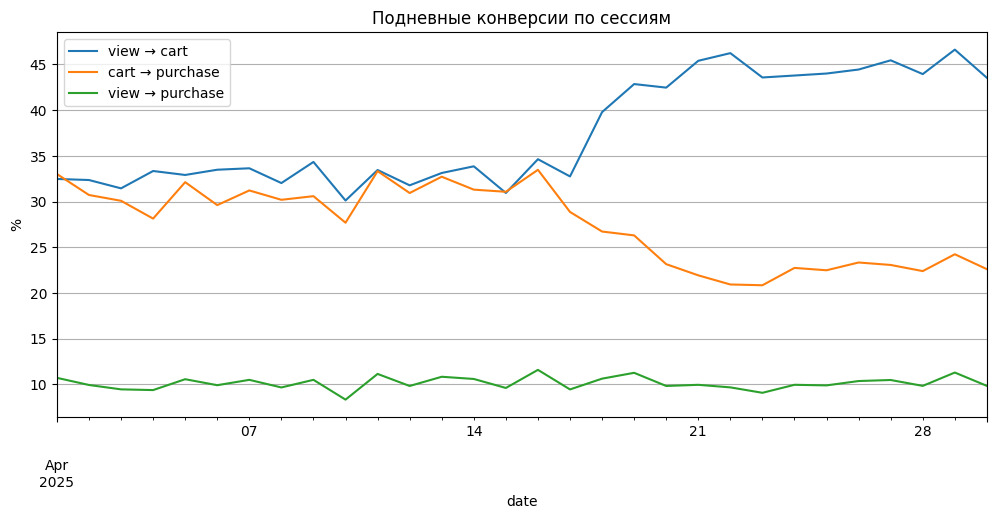

,view → cart,cart → purchase,view → purchase
date,,,
2025-04-01,0.325,0.330,0.107
2025-04-02,0.324,0.307,0.099
2025-04-03,0.315,0.301,0.095
2025-04-04,0.333,0.281,0.094
2025-04-05,0.329,0.321,0.106
2025-04-06,0.335,0.296,0.099
2025-04-07,0.336,0.312,0.105
2025-04-08,0.320,0.302,0.097
2025-04-09,0.343,0.306,0.105


In [4]:
df['date'] = df['event_ts'].dt.normalize()

daily = pd.DataFrame({
    'view_item': df[df.event == 'view_item'].groupby('date')['session_id'].nunique(),
    'add_to_cart': df[df.event == 'add_to_cart'].groupby('date')['session_id'].nunique(),
    'purchase': df[df.event == 'purchase'].groupby('date')['session_id'].nunique(),
})

daily['view → cart'] = daily['add_to_cart'] / daily['view_item']
daily['cart → purchase'] = daily['purchase'] / daily['add_to_cart']
daily['view → purchase'] = daily['purchase'] / daily['view_item']

(daily[['view → cart', 'cart → purchase', 'view → purchase']] * 100).plot(
    figsize=(12, 5),
    title='Подневные конверсии по сессиям'
)
plt.ylabel('%')
plt.grid(True)
plt.show()

daily[['view → cart', 'cart → purchase', 'view → purchase']].round(3)

Сквозная конверсия view → purchase почти не меняется: весь апрель она около 10%.

Падение видно в cart → purchase. До 17 апреля шаг корзина → покупка держится около 30–33%, с 18 апреля падает до ~22% и на этом уровне остаётся до конца месяца. Это не разовый провал, а устойчивый сдвиг.

Параллельно с 18 апреля растёт view → cart: с ~33% до ~44%. То есть в корзину стали добавлять чаще, но из корзины покупать — реже. Через весь путь до покупки это почти компенсируется, поэтому сквозная конверсия не падает.

#### **2. Проверка абсолютных и средних значений — 1 балл**

1) Постройте графики дневной динамики абсолютных значений, из которых рассчитаны конверсии выше.
2) Рассчитайте и визуализируйте среднее число событий (именно событий, не сессий), из которых рассчитаны конверсии, на пользователя. 
3) На каком этапе воронки появилась проблема?

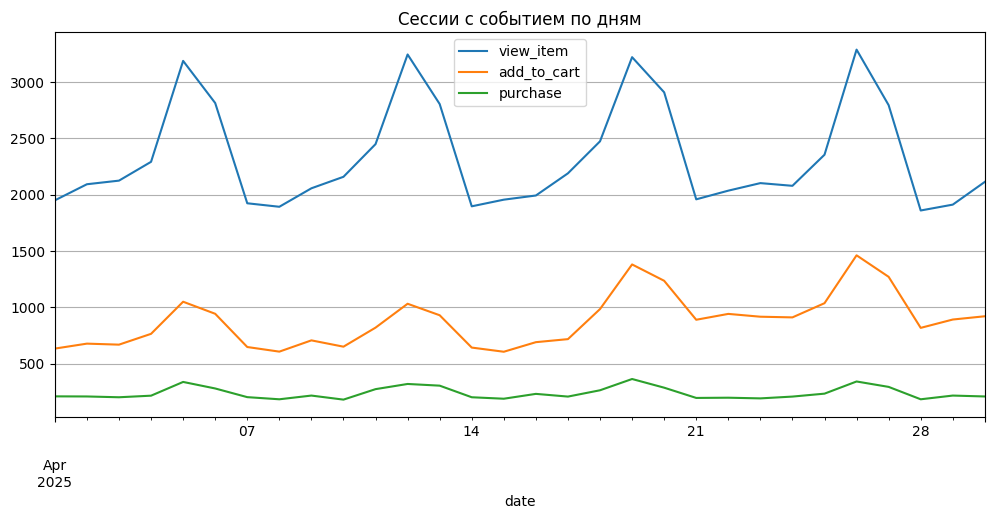

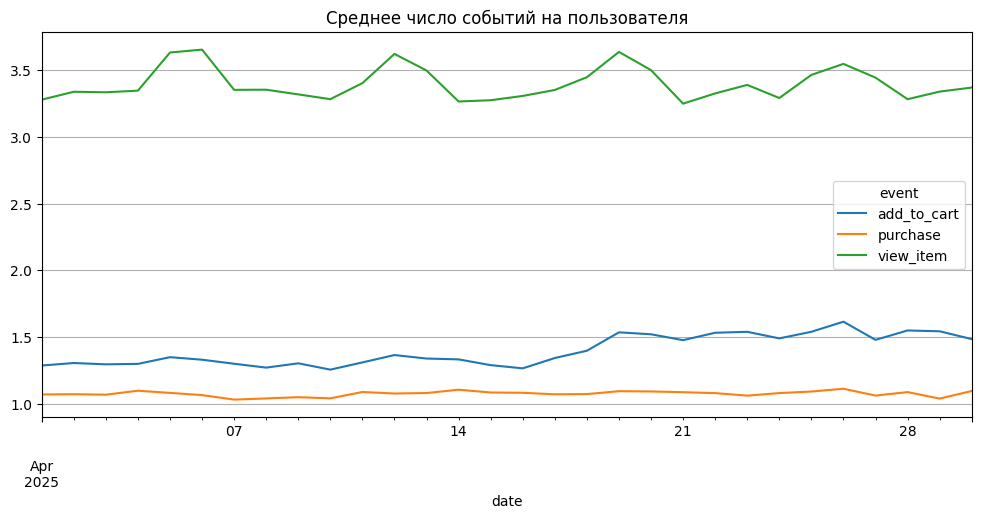

In [5]:
daily[['view_item', 'add_to_cart', 'purchase']].plot(
    figsize=(12, 5),
    title='Сессии с событием по дням'
)
plt.grid(True)
plt.show()

ev_per_user = (
    df[df.event.isin(['view_item', 'add_to_cart', 'purchase'])]
      .groupby(['date', 'event', 'user_id']).size()
      .groupby(['date', 'event']).mean()
      .unstack()
)

ev_per_user.plot(
    figsize=(12, 5),
    title='Среднее число событий на пользователя'
)
plt.grid(True)
plt.show()

Сессии с view_item и purchase не ломаются, а с add_to_cart с 18 апреля растут. То же на средних: add_to_cart на пользователя прыгает с ~1.3 до ~1.5, просмотры и покупки стоят. Проблема на этапе корзины.

#### **3. Базовые срезы — 1 балл**
1. Постройте динамику события, среднее значение которого подскочило, в разрезе:
- платформ,
- регионов,
- источников трафика,
- категорий товаров.

2. Есть ли выделяющийся срез?

*В этом пункте в качестве события продолжаем смотреть метрику среднего на пользователя*

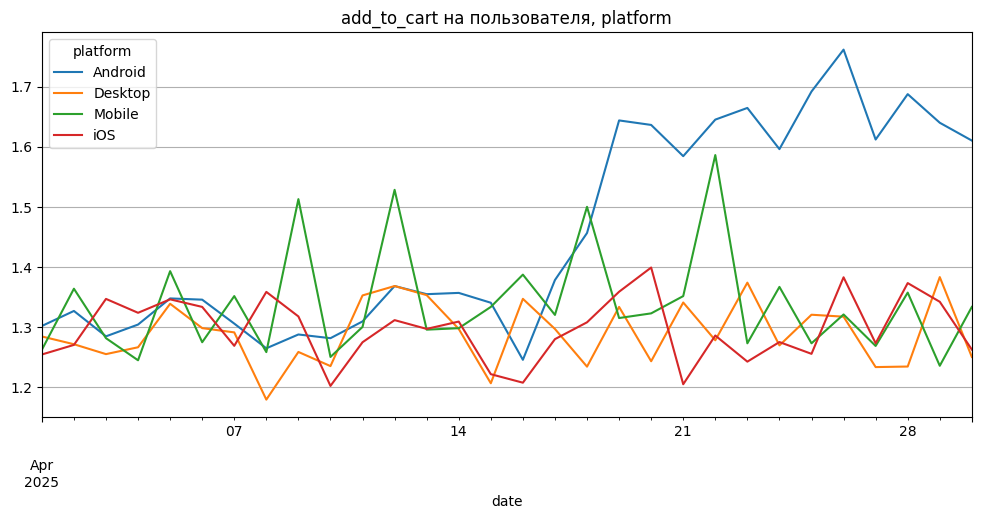

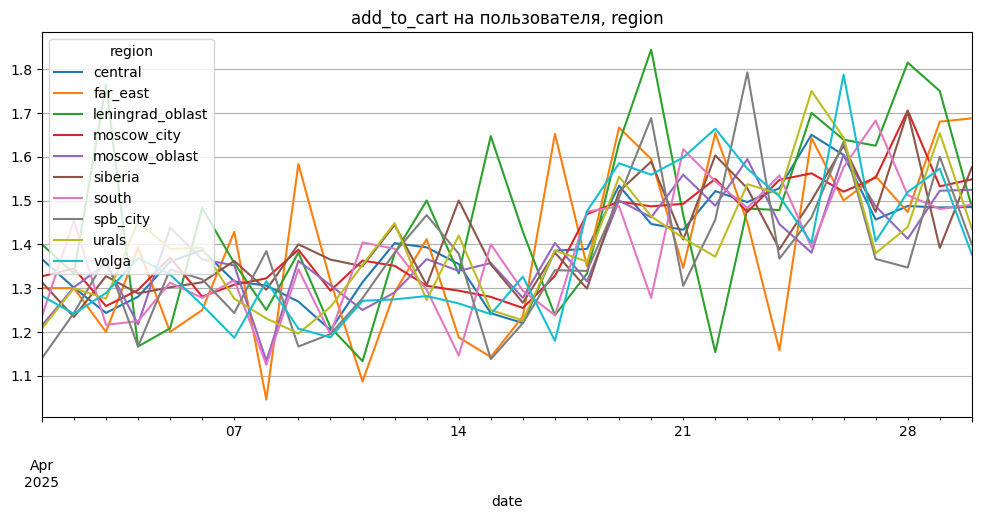

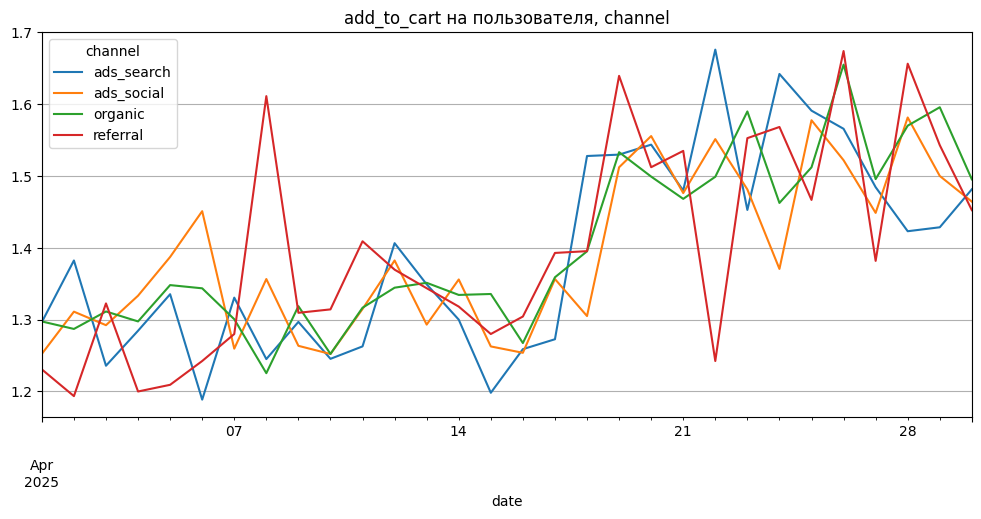

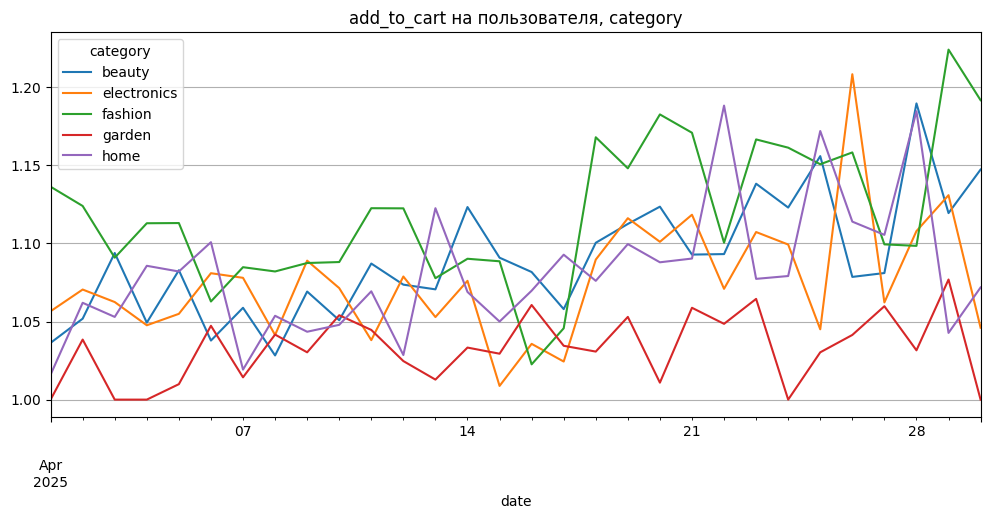

In [6]:
cart = df[df.event == 'add_to_cart']

for col in ['platform', 'region', 'channel', 'category']:
    t = (
        cart.groupby(['date', col, 'user_id']).size()
            .groupby(['date', col]).mean()
            .unstack()
    )
    t.plot(figsize=(12, 5), title=f'add_to_cart на пользователя, {col}')
    plt.grid(True)
    plt.show()

Выделяется платформа: рост add_to_cart только на Android. Регионы, каналы и категории растут примерно вместе — это не отдельный сегмент, а след Android.

#### **4. Детальные срезы — 1 балл**
1. Постройте динамику события для iOS и Android с разложением по версиям приложения.
2. Помогло ли это локализовать проблему?

*В этом пункте в качестве события продолжаем смотреть метрику среднего на пользователя*

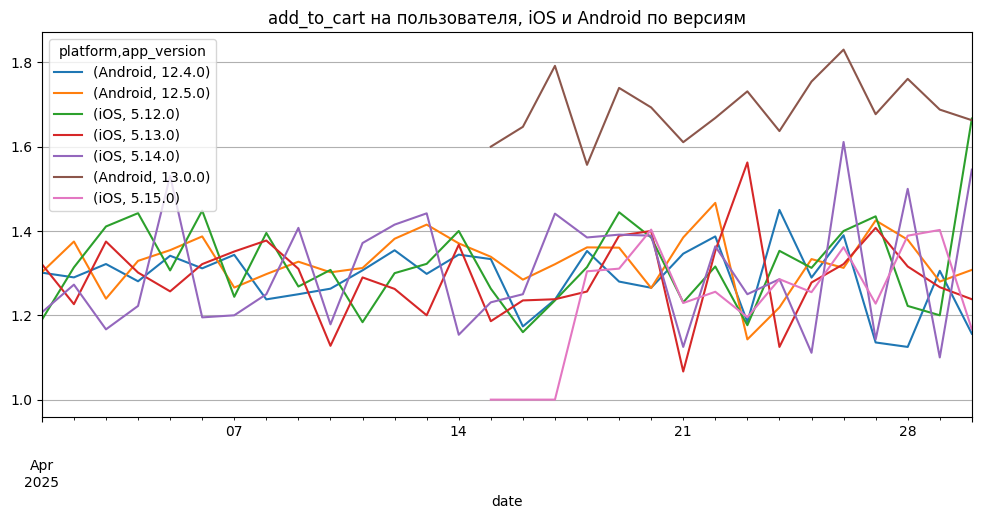

In [7]:
mob = df[(df.event == 'add_to_cart') & (df.platform.isin(['iOS', 'Android']))]

t = (
    mob.groupby(['date', 'platform', 'app_version', 'user_id']).size()
       .groupby(['date', 'platform', 'app_version']).mean()
       .unstack(['platform', 'app_version'])
)

t.plot(figsize=(12, 5), title='add_to_cart на пользователя, iOS и Android по версиям')
plt.grid(True)
plt.show()

На iOS версиях метрика стабильна. На Android с 15 апреля выходит 13.0.0, и именно там add_to_cart на пользователя ~1.6–1.8 против ~1.3 на 12.4/12.5. Вероятно проблема в релизе

#### **5. Поиск причин — 1 балл**
1. Для проблемной платформы постройте динамику ВСЕХ событий в разрезе версий приложения.
2. Сформулируйте гипотезу, что именно могло пойти не так в новом релизе? Может быть, пользователи стали заменять один функционал другим?

*В этом пункте в качестве событий продолжаем смотреть метрику среднего на пользователя*

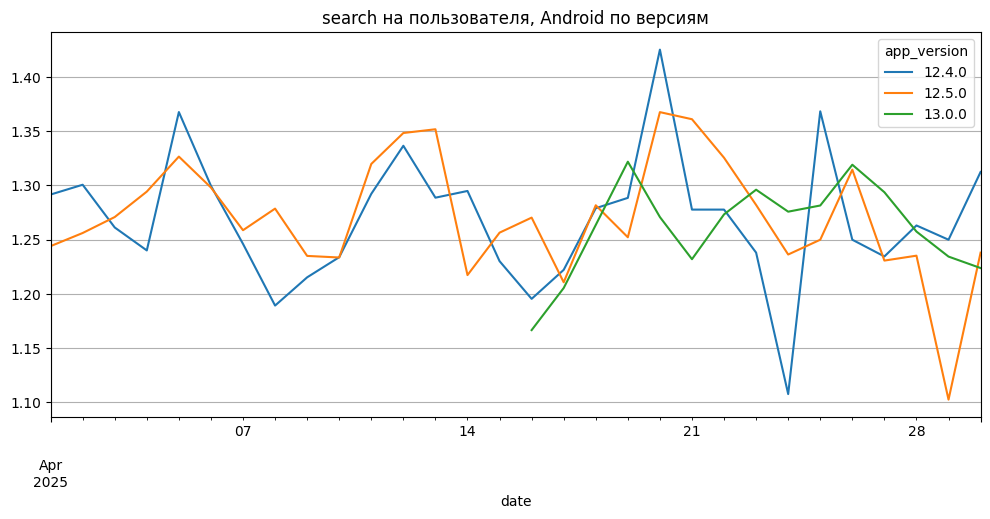

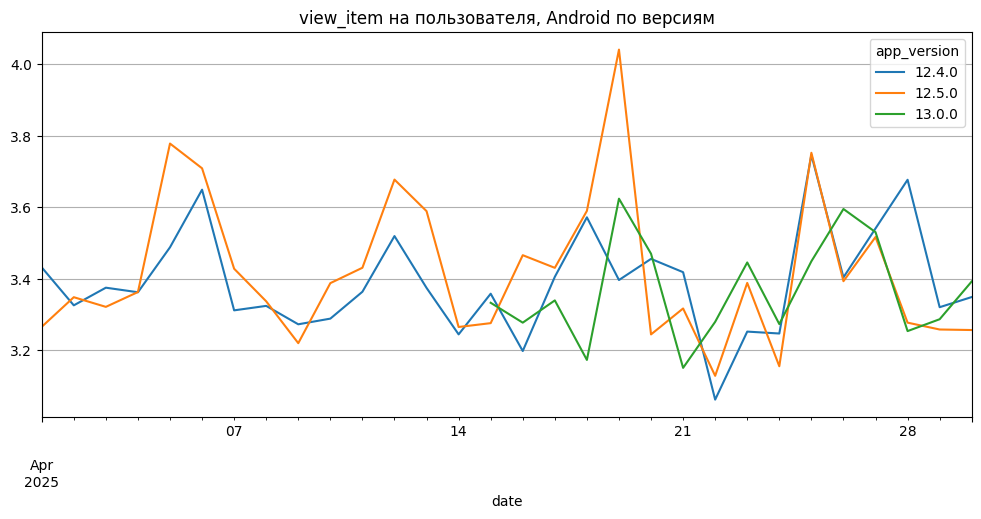

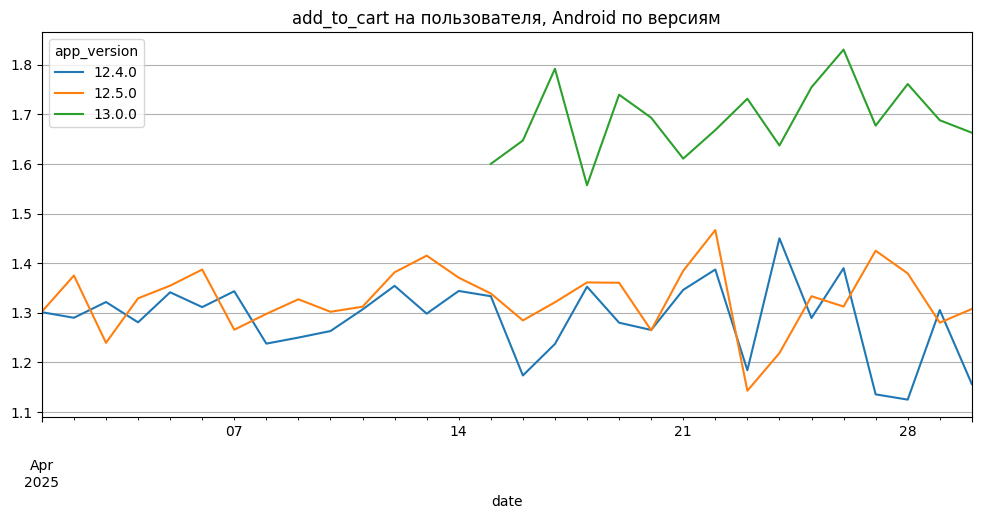

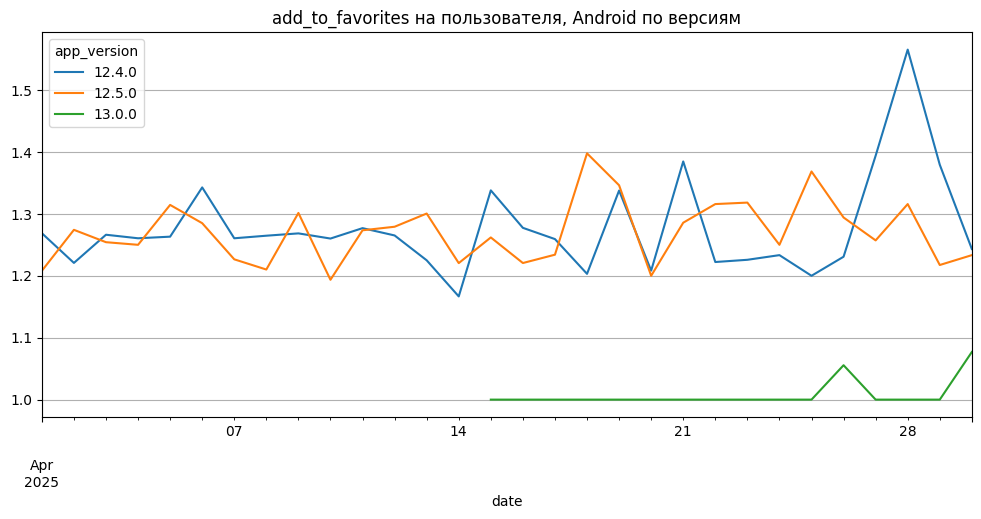

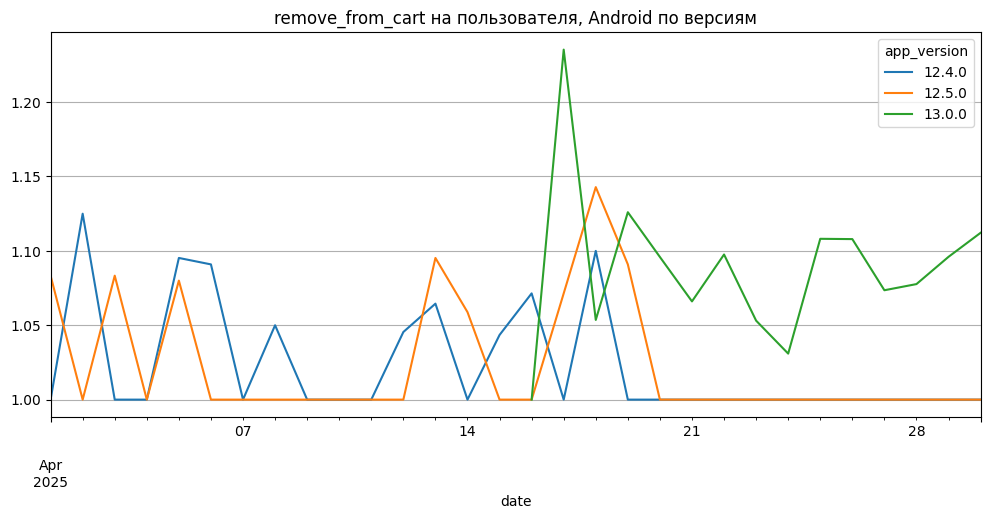

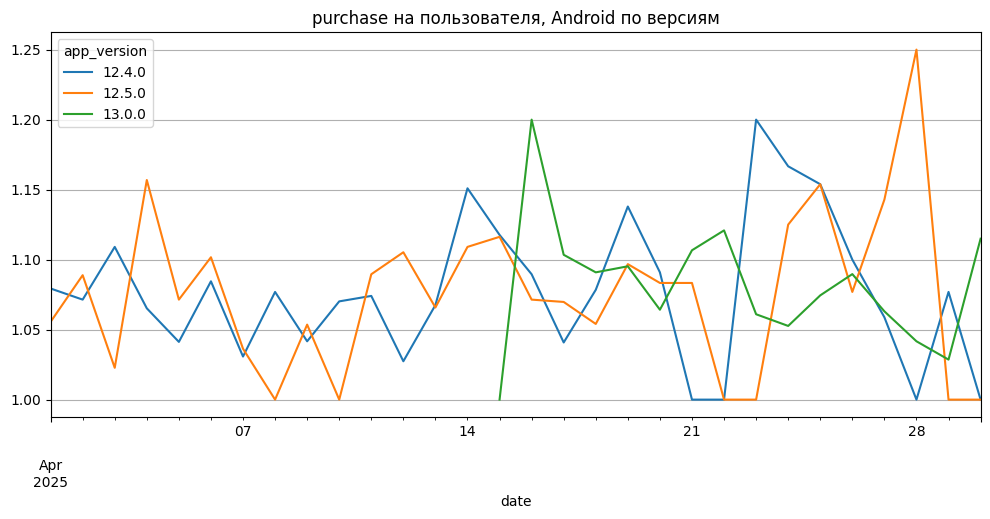

In [8]:
and_ = df[df.platform == 'Android']

for e in ['search', 'view_item', 'add_to_cart', 'add_to_favorites', 'remove_from_cart', 'purchase']:
    t = (
        and_[and_.event == e]
          .groupby(['date', 'app_version', 'user_id']).size()
          .groupby(['date', 'app_version']).mean()
          .unstack()
    )
    t.plot(figsize=(12, 5), title=f'{e} на пользователя, Android по версиям')
    plt.grid(True)
    plt.show()

На Android 13.0.0 add_to_favorites почти пропал, а add_to_cart раздулся. Остальные события так не скачут. Похоже, в релизе избранное стало уходить в корзину: люди сохраняют «на потом» через корзину, поэтому cart → purchase падает.

#### **6. Новости для команды — 1 балл**

На основе проведённого расследования подготовьте сообщение для команды о том, что именно пошло не так.

С 18 апреля просела конверсия корзина → покупка. Сквозная view → purchase не упала, потому что в корзину стали класть чаще.

Влияние только на Android, версия 13.0.0. Предположительно в этом релизе сломалось избранное — add_to_favorites почти пропал, add_to_cart вырос. Похоже, избранное уходит в корзину.

Надо починить 13.0.0 и проверить трекинг кнопки избранного.